In [16]:
from pathlib import Path
from fastai.vision.all import *
from fastai.vision.all import get_image_files
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from PIL import Image

import warnings
warnings.filterwarnings ('ignore')

In [17]:
path = Path('data')
path.ls()

(#3) [Path('data/.DS_Store'),Path('data/Real'),Path('data/AI')]

In [18]:
images = get_image_files(path)
print(f"Total images found: {len(images)}")

Total images found: 982


In [19]:
data_block = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=Resize(224)
)

In [20]:
dls = data_block.dataloaders(path)

In [21]:
learn = vision_learner(dls, resnet18, metrics=accuracy)
learn.fine_tune(3)

epoch,train_loss,valid_loss,accuracy,time
0,1.062106,0.710413,0.719388,00:25


epoch,train_loss,valid_loss,accuracy,time
0,0.724013,0.622980,0.704082,00:28
1,0.524566,0.749124,0.709184,00:28
2,0.412885,0.720685,0.729592,00:29


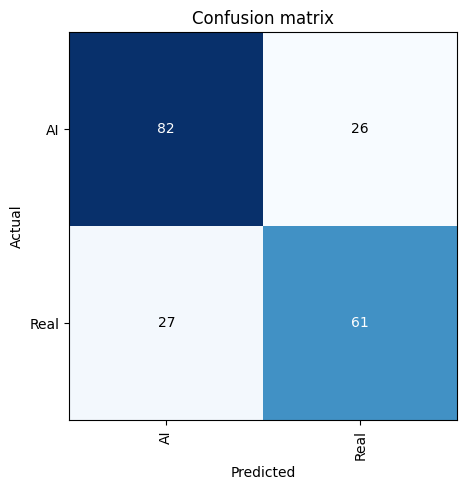

In [22]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()

In [23]:
def evaluate_model():
    preds, targs = learn.get_preds()
    print(classification_report(targs, preds.argmax(dim=1)))

In [24]:
evaluate_model()

              precision    recall  f1-score   support

           0       0.75      0.76      0.76       108
           1       0.70      0.69      0.70        88

    accuracy                           0.73       196
   macro avg       0.73      0.73      0.73       196
weighted avg       0.73      0.73      0.73       196



In [30]:
def show_and_predict(img_path):
    pred, idx, probs = learn.predict(img_path)
    confidence = probs[idx].item() * 100

    img = Image.open(img_path)
    color = "green" if str(pred).lower() == "real" else "red"

    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{pred} ({confidence:.1f}% confidence)", color=color, fontsize=14)
    plt.show()
    print(f"Image: {img_path}")
    print(f"Prediction: {pred}")

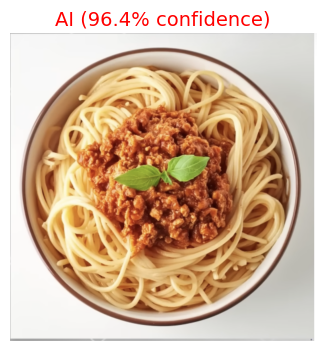

Image: test_image1.png
Prediction: AI


In [33]:
show_and_predict('test_image1.png')

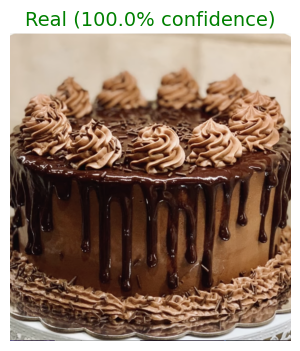

Image: test_image2.png
Prediction: Real


In [34]:
show_and_predict('test_image2.png')